# HW3: Euler-based vs Quaternion-based EKF for Attitude Estimation

Load IMU log (accelerometer in m/s², gyroscope in rad/s) and compare two EKF implementations.

In [ ]:

try:
    import google.colab
    from google.colab import drive
    drive.mount("/content/drive")
    
except ImportError:
    pass 

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

# Colab: get IMU CSV (upload or from Drive)
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    # Option 1: use file picker to upload imu_log.csv
    if not os.path.isfile("imu_log.csv"):
        from google.colab import files
        print("Upload imu_log.csv (accelerometer + gyroscope CSV)")
        uploaded = files.upload()
        csv_name = "imu_log.csv" if "imu_log.csv" in uploaded else list(uploaded.keys())[0]
    else:
        csv_name = "imu_log.csv"
else:
    csv_name = "imu_log.csv"

df = pd.read_csv(csv_name)
t = df["timestamp_s"].values
accel = df[["accel_x", "accel_y", "accel_z"]].values
gyro = df[["gyro_x", "gyro_y", "gyro_z"]].values
dt = np.median(np.diff(t))
g = 9.81
print(f"Loaded {len(t)} samples, dt ≈ {dt:.4f} s")

Loaded 2501 samples, dt ≈ 0.0100 s


## Variant A: Euler-based EKF

State: $x = [\phi, \theta, \psi]^T$ (Roll, Pitch, Yaw). Prediction: integrate gyro to get Euler rates. Update: match accelerometer to gravity in body frame.

In [3]:
def euler_to_rotation(roll, pitch, yaw):
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    Rx = np.array([[1, 0, 0], [0, cr, -sr], [0, sr, cr]])
    Ry = np.array([[cp, 0, sp], [0, 1, 0], [-sp, 0, cp]])
    Rz = np.array([[cy, -sy, 0], [sy, cy, 0], [0, 0, 1]])
    return Rz @ Ry @ Rx  # body to world

def euler_rates_matrix(roll, pitch):
    """ [phi_dot, theta_dot, psi_dot] = W @ omega_body """
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    tp = np.tan(pitch)
    W = np.array([
        [1, sr * tp, cr * tp],
        [0, cr, -sr],
        [0, sr / cp, cr / cp]
    ])
    return W

def expected_accel_euler(roll, pitch, yaw):
    R = euler_to_rotation(roll, pitch, yaw)
    return R.T @ np.array([0, 0, g])

def euler_accel_jacobian(roll, pitch, yaw):
    cr, sr = np.cos(roll), np.sin(roll)
    cp, sp = np.cos(pitch), np.sin(pitch)
    cy, sy = np.cos(yaw), np.sin(yaw)
    # h = R.T @ [0,0,g]; dh/d(roll,pitch,yaw) via finite diff for stability
    eps = 1e-6
    h0 = expected_accel_euler(roll, pitch, yaw)
    H = np.column_stack([
        (expected_accel_euler(roll + eps, pitch, yaw) - h0) / eps,
        (expected_accel_euler(roll, pitch + eps, yaw) - h0) / eps,
        (expected_accel_euler(roll, pitch, yaw + eps) - h0) / eps,
    ])
    return H

# Euler EKF
N = len(t)
Q_euler = np.diag([1e-4, 1e-4, 1e-4])
R_accel = np.eye(3) * 0.5
x_euler = np.array([0.0, 0.0, 0.0])
P_euler = np.eye(3) * 0.01

roll_hist, pitch_hist, yaw_hist = [], [], []
for i in range(N):
    # Prediction
    W = euler_rates_matrix(x_euler[0], x_euler[1])
    euler_dot = W @ gyro[i]
    x_euler = x_euler + dt * euler_dot
    eps = 1e-6
    f0 = x_euler + dt * euler_dot
    F = np.eye(3)
    for j in range(3):
        x_plus = x_euler.copy(); x_plus[j] += eps
        Wp = euler_rates_matrix(x_plus[0], x_plus[1])
        f_plus = x_plus + dt * (Wp @ gyro[i])
        F[:, j] = (f_plus - f0) / eps
    P_euler = F @ P_euler @ F.T + Q_euler
    # Update
    h = expected_accel_euler(x_euler[0], x_euler[1], x_euler[2])
    H = euler_accel_jacobian(x_euler[0], x_euler[1], x_euler[2])
    S = H @ P_euler @ H.T + R_accel
    # Numerical stabilization (avoid singular S)
    S = S + np.eye(3) * 1e-9
    PHt = P_euler @ H.T
    # K = PHt @ inv(S)  (avoid explicit inverse)
    K = np.linalg.solve(S.T, PHt.T).T
    y = accel[i] - h
    x_euler = x_euler + K @ y
    I3 = np.eye(3)
    # Joseph form keeps P symmetric PSD
    P_euler = (I3 - K @ H) @ P_euler @ (I3 - K @ H).T + K @ R_accel @ K.T
    roll_hist.append(x_euler[0]); pitch_hist.append(x_euler[1]); yaw_hist.append(x_euler[2])

roll_euler = np.array(roll_hist)
pitch_euler = np.array(pitch_hist)
yaw_euler = np.array(yaw_hist)
print("Euler EKF done.")

Euler EKF done.


## Variant B: Quaternion-based EKF

State: $q = [q_w, q_x, q_y, q_z]^T$. Prediction: $\dot{q} = \frac{1}{2} q \otimes \omega$, then normalize. Update: gravity in body frame vs accelerometer. Track quaternion norm before normalization for error analysis.

In [4]:
def q_mult(q, r):
    w0, x0, y0, z0 = q
    w1, x1, y1, z1 = r
    return np.array([
        w0*w1 - x0*x1 - y0*y1 - z0*z1,
        w0*x1 + x0*w1 + y0*z1 - z0*y1,
        w0*y1 - x0*z1 + y0*w1 + z0*x1,
        w0*z1 + x0*y1 - y0*x1 + z0*w1
    ])

def q_rotate_vector(q, v):
    """ Rotate vector v by quaternion q (body to world); v is 3-vec. """
    qv = np.array([0, v[0], v[1], v[2]])
    q_inv = np.array([q[0], -q[1], -q[2], -q[3]])
    return q_mult(q_mult(q, qv), q_inv)[1:4]

def quat_to_rotation(q):
    w, x, y, z = q
    return np.array([
        [1-2*(y*y+z*z), 2*(x*y-w*z), 2*(x*z+w*y)],
        [2*(x*y+w*z), 1-2*(x*x+z*z), 2*(y*z-w*x)],
        [2*(x*z-w*y), 2*(y*z+w*x), 1-2*(x*x+y*y)]
    ])

def expected_accel_quat(q):
    g_world = np.array([0, 0, g])
    return q_rotate_vector(np.array([q[0], -q[1], -q[2], -q[3]]), g_world)

def quat_accel_jacobian(q):
    h0 = expected_accel_quat(q)
    eps = 1e-6
    H = np.zeros((3, 4))
    for j in range(4):
        qp = q.copy(); qp[j] += eps
        qp = qp / np.linalg.norm(qp)
        H[:, j] = (expected_accel_quat(qp) - h0) / eps
    return H

def quat_to_euler(q):
    w, x, y, z = q
    sinp = 2 * (w * y - z * x)
    if np.abs(sinp) >= 1:
        pitch = np.copysign(np.pi/2, sinp)
    else:
        pitch = np.arcsin(sinp)
    roll = np.arctan2(2 * (w*x + y*z), 1 - 2*(x*x + y*y))
    yaw = np.arctan2(2 * (w*z + x*y), 1 - 2*(y*y + z*z))
    return roll, pitch, yaw

# Quaternion EKF
q = np.array([1.0, 0.0, 0.0, 0.0])
P_quat = np.eye(4) * 0.01
Q_quat = np.eye(4) * 1e-5
R_accel_q = np.eye(3) * 0.5

roll_q_hist, pitch_q_hist, yaw_q_hist = [], [], []
quat_norm_before_norm = []

for i in range(N):
    # Prediction: q_dot = 0.5 * q ⊗ [0, wx, wy, wz]
    omega_q = np.array([0, gyro[i,0], gyro[i,1], gyro[i,2]])
    q_dot = 0.5 * q_mult(q, omega_q)
    q = q + dt * q_dot
    quat_norm_before_norm.append(np.linalg.norm(q))
    q = q / np.linalg.norm(q)
    # State transition Jacobian (simplified: use identity + process noise)
    Fq = np.eye(4)  # full Jacobian for quat is more involved; Q absorbs uncertainty
    P_quat = Fq @ P_quat @ Fq.T + Q_quat
    # Update
    h = expected_accel_quat(q)
    H = quat_accel_jacobian(q)
    S = H @ P_quat @ H.T + R_accel_q
    S = S + np.eye(3) * 1e-9
    PHt = P_quat @ H.T
    K = np.linalg.solve(S.T, PHt.T).T
    y = accel[i] - h
    q = q + K @ y
    I4 = np.eye(4)
    P_quat = (I4 - K @ H) @ P_quat @ (I4 - K @ H).T + K @ R_accel_q @ K.T
    q = q / np.linalg.norm(q)
    r, p, y = quat_to_euler(q)
    roll_q_hist.append(r); pitch_q_hist.append(p); yaw_q_hist.append(y)

roll_quat = np.array(roll_q_hist)
pitch_quat = np.array(pitch_q_hist)
yaw_quat = np.array(yaw_q_hist)
quat_norm_before_norm = np.array(quat_norm_before_norm)
print("Quaternion EKF done.")

Quaternion EKF done.


### Roll, Pitch, Yaw comparison (Euler EKF vs Quaternion EKF)

Both methods output orientation; quaternion estimates are converted to Euler angles for comparison.

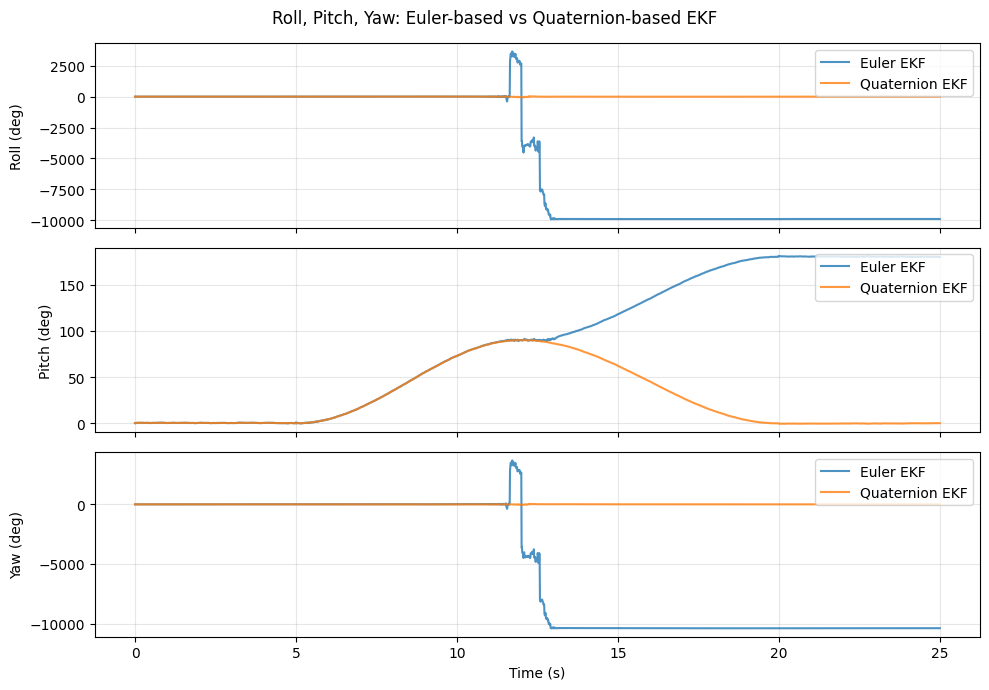

In [5]:
fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, np.rad2deg(roll_euler), label="Euler EKF", alpha=0.8)
axes[0].plot(t, np.rad2deg(roll_quat), label="Quaternion EKF", alpha=0.8)
axes[0].set_ylabel("Roll (deg)")
axes[0].legend(loc="upper right")
axes[0].grid(True, alpha=0.3)
axes[1].plot(t, np.rad2deg(pitch_euler), label="Euler EKF", alpha=0.8)
axes[1].plot(t, np.rad2deg(pitch_quat), label="Quaternion EKF", alpha=0.8)
axes[1].set_ylabel("Pitch (deg)")
axes[1].legend(loc="upper right")
axes[1].grid(True, alpha=0.3)
axes[2].plot(t, np.rad2deg(yaw_euler), label="Euler EKF", alpha=0.8)
axes[2].plot(t, np.rad2deg(yaw_quat), label="Quaternion EKF", alpha=0.8)
axes[2].set_ylabel("Yaw (deg)")
axes[2].set_xlabel("Time (s)")
axes[2].legend(loc="upper right")
axes[2].grid(True, alpha=0.3)
plt.suptitle("Roll, Pitch, Yaw: Euler-based vs Quaternion-based EKF")
plt.tight_layout()
plt.show()

### Quaternion norm before normalization (Variant B)

Shows accumulation of numerical error before the normalization step.

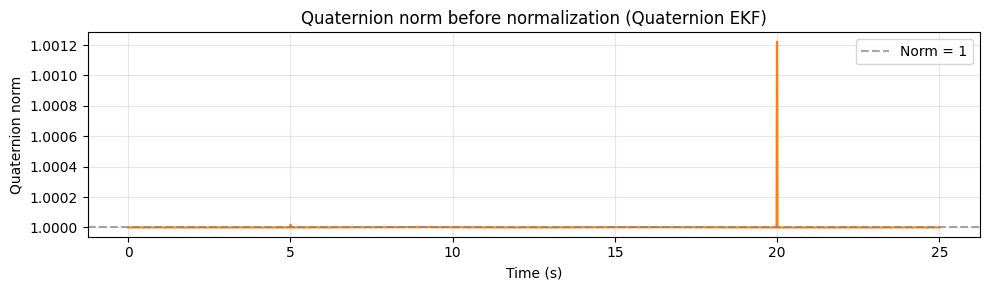

In [6]:
plt.figure(figsize=(10, 3))
plt.plot(t, quat_norm_before_norm, color="C1")
plt.axhline(y=1.0, color="gray", linestyle="--", alpha=0.7, label="Norm = 1")
plt.xlabel("Time (s)")
plt.ylabel("Quaternion norm")
plt.title("Quaternion norm before normalization (Quaternion EKF)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()